# FLSTM Gates + FuzzyOutput using DOG\nDataset: Mackey-Glass

In [1]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")


Process ID (PID): 11087


In [2]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


Notebook execution started at: 2026-07-15 23:23:48


In [3]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================
import tensorflow as tf
import platform

try:
    tf.config.set_visible_devices([], 'GPU')
    print('Forcing CPU execution (disabled GPU visibility).')
except RuntimeError as e:
    print(e)


Forcing CPU execution (disabled GPU visibility).


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt





In [5]:
# ============================================================
# Wang-Mendel Fuzzy Rule Base with Triangular MFs
# (FLSTM paper: doi:10.1038/s41598-023-47812-3)
# ============================================================
Q_REGIONS = 5

def triangular_mf_np(x, a, b, c):
    """Triangular membership function: vertices at (a, 0), (b, 1), (c, 0)."""
    return np.maximum(0.0, np.minimum((x - a) / (b - a + 1e-10),
                                      (c - x) / (c - b + 1e-10)))

def build_triangular_fuzzy_sets(data_min, data_max, q=Q_REGIONS):
    """Build q equally-spaced triangular fuzzy sets over [data_min, data_max]."""
    centers = np.linspace(data_min, data_max, q)
    step = centers[1] - centers[0] if q > 1 else 1.0
    fuzzy_sets = []
    for center in centers:
        fuzzy_sets.append((center - step, center, center + step))
    return fuzzy_sets, centers

def fuzzify_value(value, fuzzy_sets):
    """Return (best_set_index, membership_degree) for a single value."""
    best_idx, best_mu = 0, 0.0
    for i, (a, b, c) in enumerate(fuzzy_sets):
        mu = triangular_mf_np(value, a, b, c)
        if mu > best_mu:
            best_mu = mu
            best_idx = i
    return best_idx, max(best_mu, 1e-10)

def extract_wm_rules(X, y, fs_x_list, fs_y):
    """Extract fuzzy rules using the Wang-Mendel method.
    X: (N, n_features), y: (N,)
    fs_x_list: list of fuzzy_sets (one per feature)
    fs_y: fuzzy_sets for output
    Returns dict: tuple(antecedent_indices) -> (consequent_index, weight)
    """
    rules = {}
    n_features = X.shape[1]
    for i in range(len(X)):
        antecedents = []
        weight = 1.0
        for j in range(n_features):
            idx, mu = fuzzify_value(X[i, j], fs_x_list[j])
            antecedents.append(idx)
            weight *= mu
        cons_idx, cons_mu = fuzzify_value(y[i], fs_y)
        weight *= cons_mu
        key = tuple(antecedents)
        if key not in rules or weight > rules[key][1]:
            rules[key] = (cons_idx, weight)
    return rules

def complement_wm_rules(rules, q, n_features, centers_y):
    """Add complement rules for missing antecedent combinations.
    For each missing combination, assign the consequent of the nearest existing rule.
    """
    import itertools
    all_combos = list(itertools.product(range(q), repeat=n_features))
    for combo in all_combos:
        if combo not in rules:
            best_dist = float('inf')
            best_cons = q // 2
            for existing_key, (cons, w) in rules.items():
                dist = sum((a - b) ** 2 for a, b in zip(combo, existing_key))
                if dist < best_dist:
                    best_dist = dist
                    best_cons = cons
            rules[combo] = (best_cons, 0.1)
    return rules

def wm_fuzzy_predict(x_features, rules, fs_x_list, centers_y, q=Q_REGIONS):
    """Predict using fuzzy rule base with center-average defuzzification.
    x_features: 1D array of input features for one sample.
    """
    n_features = len(x_features)
    # Compute membership degrees for each feature across all q regions
    memberships = []
    for j in range(n_features):
        mf_vals = []
        for k in range(q):
            a, b, c = fs_x_list[j][k]
            mf_vals.append(triangular_mf_np(x_features[j], a, b, c))
        memberships.append(mf_vals)
    # Weighted average defuzzification over all rules
    total_weight = 0.0
    weighted_sum = 0.0
    for antecedents, (consequent, _) in rules.items():
        strength = 1.0
        for j, ant_idx in enumerate(antecedents):
            strength *= memberships[j][ant_idx]
        if strength > 1e-10:
            weighted_sum += strength * centers_y[consequent]
            total_weight += strength
    if total_weight > 1e-10:
        return weighted_sum / total_weight
    return 0.0

def build_wm_system(X_train, y_train, q=Q_REGIONS):
    """Build complete Wang-Mendel fuzzy system from training data.
    Returns: (rules, fs_x_list, centers_y)
    """
    n_features = X_train.shape[1]
    fs_x_list = []
    for j in range(n_features):
        col = X_train[:, j]
        fs, _ = build_triangular_fuzzy_sets(col.min(), col.max(), q)
        fs_x_list.append(fs)
    fs_y, centers_y = build_triangular_fuzzy_sets(y_train.min(), y_train.max(), q)
    rules = extract_wm_rules(X_train, y_train, fs_x_list, fs_y)
    rules = complement_wm_rules(rules, q, n_features, centers_y)
    return rules, fs_x_list, centers_y

def compute_fuzzy_predictions(X, rules, fs_x_list, centers_y, q=Q_REGIONS):
    """Compute Wang-Mendel fuzzy predictions for an array of samples."""
    preds = np.zeros(len(X))
    for i in range(len(X)):
        preds[i] = wm_fuzzy_predict(X[i], rules, fs_x_list, centers_y, q)
    return preds


In [6]:
# ============================================================
# Membership Functions
# ============================================================
def dog(x, mu1=-1.0, mu2=1.0, sigma1=0.5, sigma2=0.5):
    return tf.exp(-tf.square(x - mu1)/ (2 * sigma1**2)) - tf.exp(-tf.square(x - mu2)/ (2 * sigma2**2))

def signed_gaussian(x, sigma=0.5):
    return x * tf.exp(-tf.square(x)/ (2 * sigma**2))

def generalized_bell(x, a=1.0, b=2.0, c_val=0.0):
    return 1.0 / (1.0 + tf.pow(tf.abs((x - c_val) / a), 2*b))

# ============================================================
# FLSTM Cell: MF-based gates + Fuzzy Prediction Fusion
# (r_t is integrated into gate computations via separate weights)
# ============================================================
@tf.keras.utils.register_keras_serializable()
class MembershipFLSTMSNPCell(layers.Layer):
    def __init__(self, units, mf_type='dog', **kwargs):
        super().__init__(**kwargs)
        self.units, self.mf_type = units, mf_type
        self.state_size, self.output_size = (units, units, units), units
        self.mf = dog if mf_type == 'dog' else signed_gaussian if mf_type == 'sg' else generalized_bell

    def build(self, input_shape):
        # input_shape[-1] includes the fuzzy prediction r_t as the LAST feature
        total_input_dim = input_shape[-1]
        actual_input_dim = total_input_dim - 1  # exclude r_t
        self.kernel = self.add_weight(shape=(actual_input_dim, self.units * 4), initializer='glorot_uniform', name='kernel')
        self.recurrent_kernel = self.add_weight(shape=(self.units, self.units * 4), initializer='orthogonal', name='recurrent_kernel')
        self.bias = self.add_weight(shape=(self.units * 4,), initializer='zeros', name='bias')
        # Fuzzy prediction fusion weights: W_gf, W_gi, W_go (Eq. 14-16)
        # r_t is scalar → separate weight for each of 3 gates (not candidate)
        self.fuzzy_gate_kernel = self.add_weight(shape=(1, self.units * 3), initializer='glorot_uniform', name='fuzzy_gate_kernel')

    def call(self, inputs, states):
        u_tm1 = states[0]
        # Split: actual input features vs fuzzy prediction r_t
        x_t = inputs[:, :-1]
        r_t = inputs[:, -1:]  # (batch, 1)
        z = tf.matmul(x_t, self.kernel) + tf.matmul(u_tm1, self.recurrent_kernel) + self.bias
        z0, z1, z2, z3 = z[:, :self.units], z[:, self.units:2*self.units], z[:, 2*self.units:3*self.units], z[:, 3*self.units:]
        # Add fuzzy prediction contribution to gates (Eq. 14-16)
        fz = tf.matmul(r_t, self.fuzzy_gate_kernel)
        z0 = z0 + fz[:, :self.units]
        z1 = z1 + fz[:, self.units:2*self.units]
        z2 = z2 + fz[:, 2*self.units:]

        r = tf.tanh(z0)
        c = tf.clip_by_value(self.mf(z1), -1.0, 1.0)
        o = tf.clip_by_value(self.mf(z2), -1.0, 1.0)
        a = tf.tanh(z3)

        u = r * u_tm1 - c * a
        h = o * a
        return h, [u, c, o]

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'mf_type': self.mf_type})
        return config

# ============================================================
# Strengthening Memory Layer (Eq. 17-19)
# ============================================================
@tf.keras.utils.register_keras_serializable()
class StrengtheningMemoryLayer(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units_out = units
        self.dense = layers.Dense(units, activation='tanh')

    def call(self, inputs):
        h_t, c_t = inputs
        ch_t = h_t + c_t       # Eq. 17
        s_t = self.dense(ch_t)  # Eq. 18 (Conv1d on single vector ≈ Dense)
        h_hat = ch_t + s_t      # Eq. 19
        return h_hat

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units_out})
        return config


In [7]:
# ============================================================
# WM Fuzzy Output Layer (Triangular MFs, learnable consequents)
# ============================================================
@tf.keras.utils.register_keras_serializable()
class WMFuzzyOutputLayer(layers.Layer):
    def __init__(self, units_in, q=5, **kwargs):
        super().__init__(**kwargs)
        self.units_in = units_in
        self.q = q

    def build(self, input_shape):
        num_rules = self.q * self.q
        self.rule_y = self.add_weight(shape=(num_rules,), initializer='glorot_uniform', name='rule_y')

    def _triangular_mf(self, x, center, width):
        left = center - width
        right = center + width
        return tf.maximum(0.0, tf.minimum((x - left) / (center - left + 1e-10),
                                          (right - x) / (right - center + 1e-10)))

    def call(self, inputs):
        half = self.units_in // 2
        s1 = tf.reduce_mean(inputs[:, :half], axis=-1, keepdims=True)
        s2 = tf.reduce_mean(inputs[:, half:], axis=-1, keepdims=True)
        centers = tf.linspace(-1.0, 1.0, self.q)
        width = 2.0 / tf.cast(self.q - 1, tf.float32)
        numerator = tf.zeros_like(s1)
        denominator = tf.zeros_like(s1)
        for i in range(self.q):
            mu_s1 = self._triangular_mf(s1, centers[i], width)
            for j in range(self.q):
                mu_s2 = self._triangular_mf(s2, centers[j], width)
                rule_idx = i * self.q + j
                w = mu_s1 * mu_s2
                y = self.rule_y[rule_idx]
                numerator = numerator + w * y
                denominator = denominator + w
        return numerator / (denominator + 1e-8)

    def get_config(self):
        config = super().get_config()
        config.update({'units_in': self.units_in, 'q': self.q})
        return config


In [8]:
def build_model(input_dim, units, batch_size):
    cell = MembershipFLSTMSNPCell(units, mf_type='dog')
    rnn = layers.RNN(cell, return_sequences=False, return_state=True, stateful=True)

    # input_dim already includes r_t as last feature
    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x, u_out, c_out, o_out = rnn(inputs)
    # Strengthening Memory Layer
    h_strengthened = StrengtheningMemoryLayer(units)([x, u_out])
    # WM Fuzzy Output Layer (replaces Dense(1))
    outputs = WMFuzzyOutputLayer(units)(h_strengthened)

    model = tf.keras.Model(inputs=inputs, outputs=[outputs, c_out, o_out])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(clipnorm=1.0), loss=['mean_squared_error', None, None])
    return model



EVALUATING: NO NOISE (lambda=0)


===== RUN 1/2 =====


Run 1 — RMSE: 0.087599, MAE: 0.021594 (Gate Mean C: -0.3331)

===== RUN 2/2 =====


Run 2 — RMSE: 0.096338, MAE: 0.037718 (Gate Mean C: 0.4464)

===== GATE STATISTICS =====
C-Gate - Mean: 0.0567, Min: -0.9996, Max: 0.9997
O-Gate - Mean: -0.1034, Min: -0.9997, Max: 0.9997

Overall RMSE: 0.091969

===== FINAL RESULTS — FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass (2 runs) =====
RMSE: 0.091969 ± 0.004370 (Var: 0.000019)
MAE:  0.029656 ± 0.008062

Best run: 1
  RMSE: 0.087599
  MAE:  0.021594


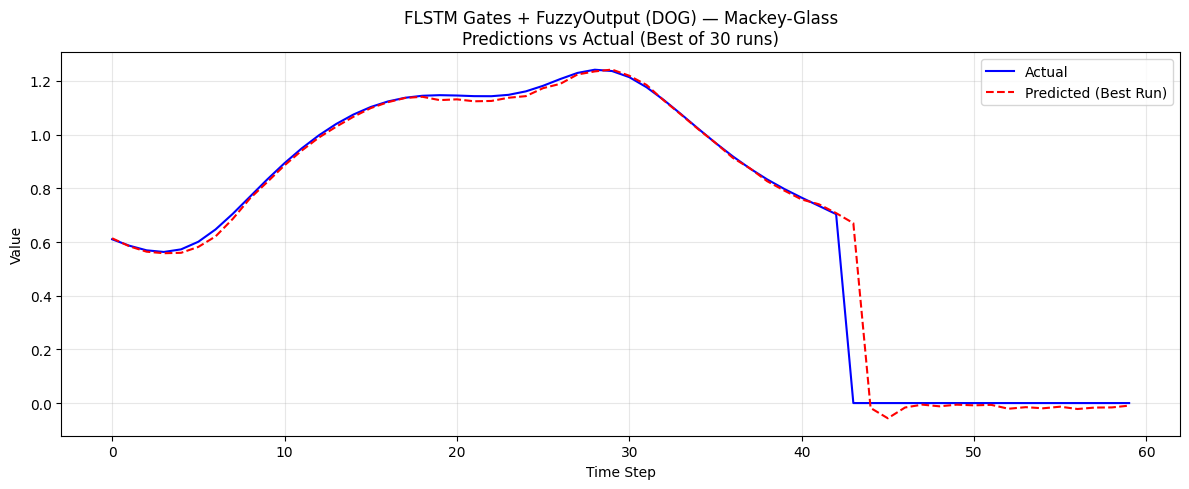

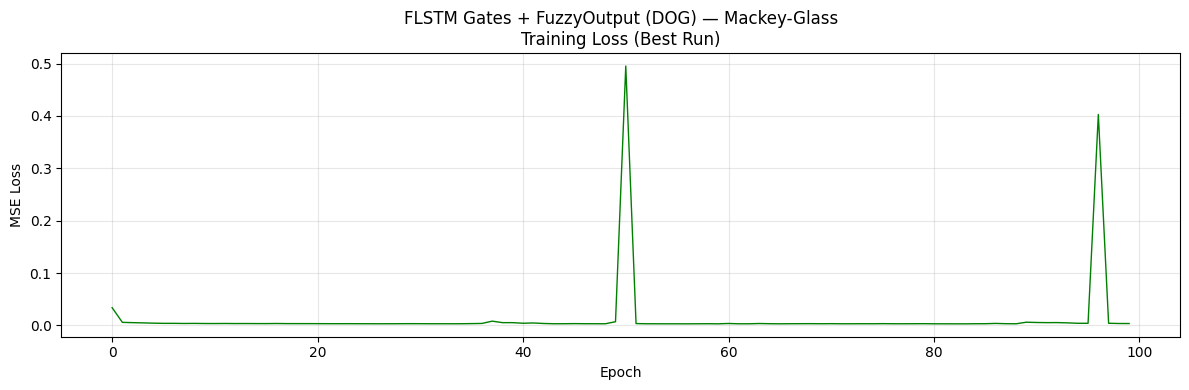

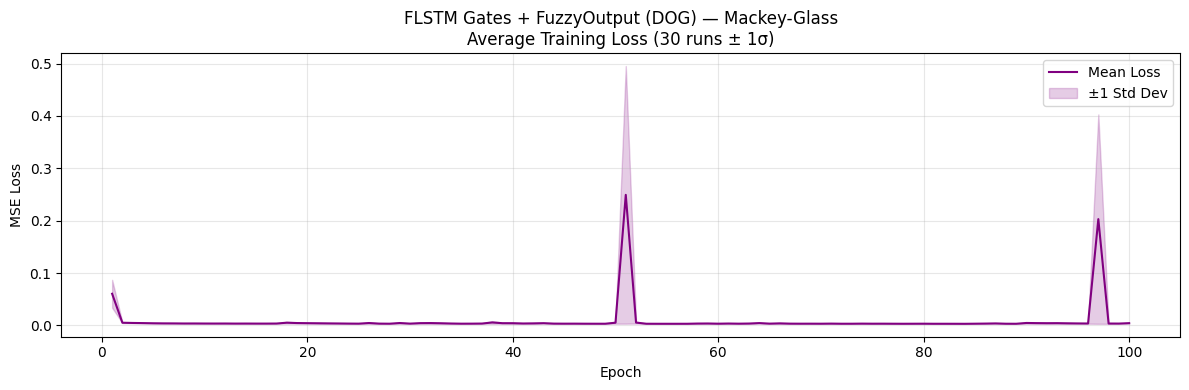

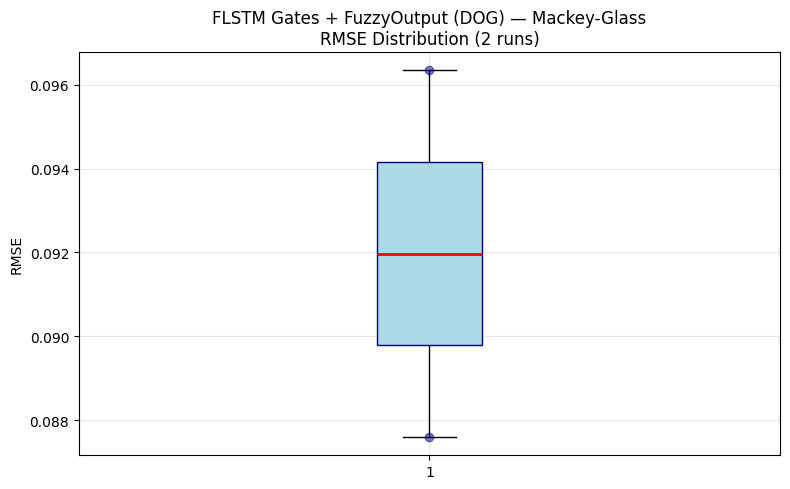

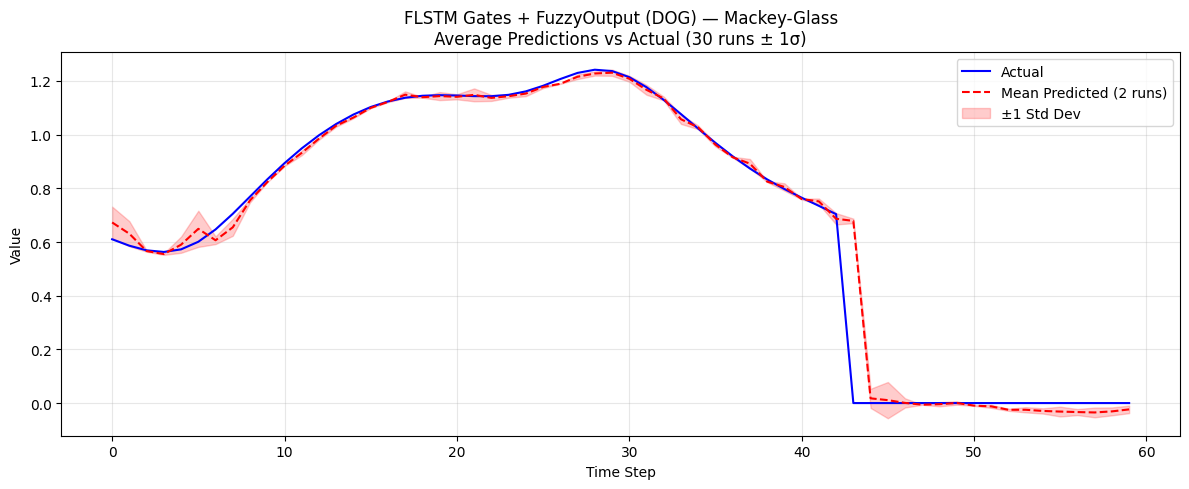

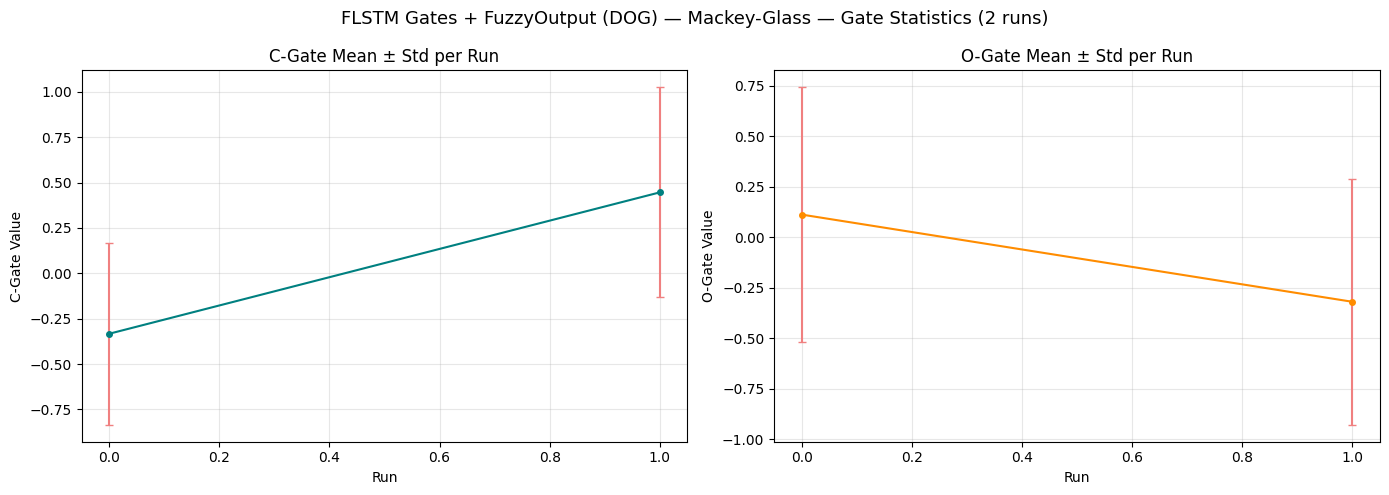

=== Best Run Metrics ===
RMSE: 0.087599
MAE:  0.021594

=== Average Metrics (2 runs) ===
RMSE: 0.091969 ± 0.004370
MAE:  0.029656 ± 0.008062

EVALUATING NOISE LEVEL: 0.5% (lambda=0.005, sigma=0.001446)


===== RUN 1/2 =====


Run 1 — RMSE: 0.519441, MAE: 0.510721 (Gate Mean C: -0.0460)

===== RUN 2/2 =====


Run 2 — RMSE: 0.519441, MAE: 0.510721 (Gate Mean C: -0.0429)

===== GATE STATISTICS =====
C-Gate - Mean: -0.0445, Min: -0.9997, Max: 0.9927
O-Gate - Mean: 0.0322, Min: -0.9997, Max: 0.9997

Overall RMSE: 0.519441

===== FINAL RESULTS — FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass (2 runs) =====
RMSE: 0.519441 ± 0.000000 (Var: 0.000000)
MAE:  0.510721 ± 0.000000

Best run: 1
  RMSE: 0.519441
  MAE:  0.510721


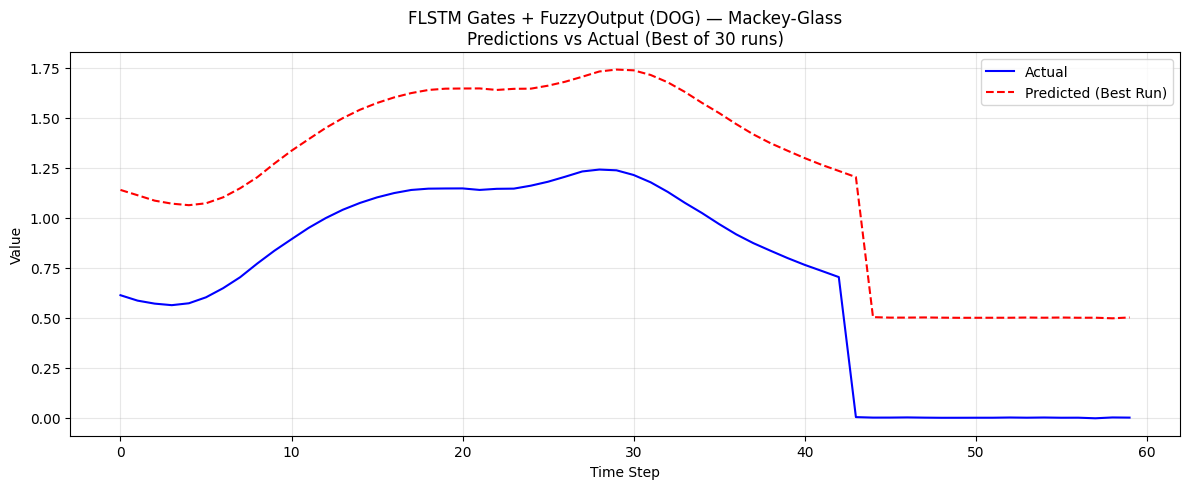

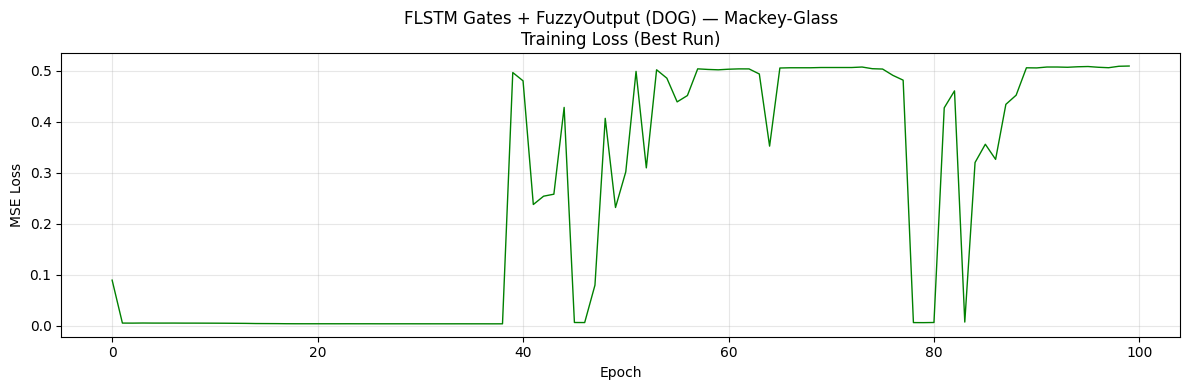

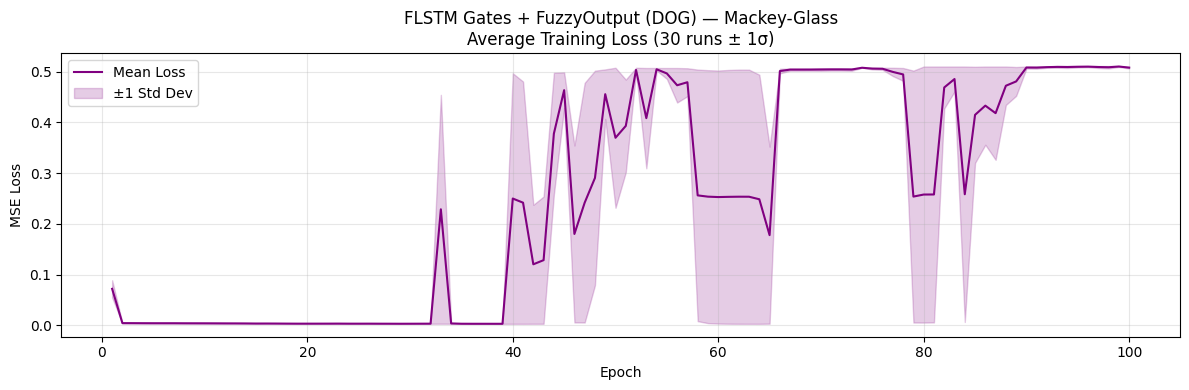

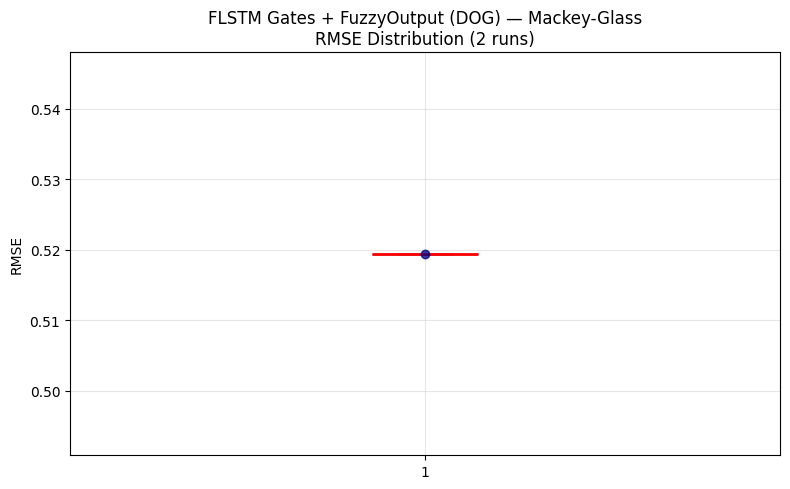

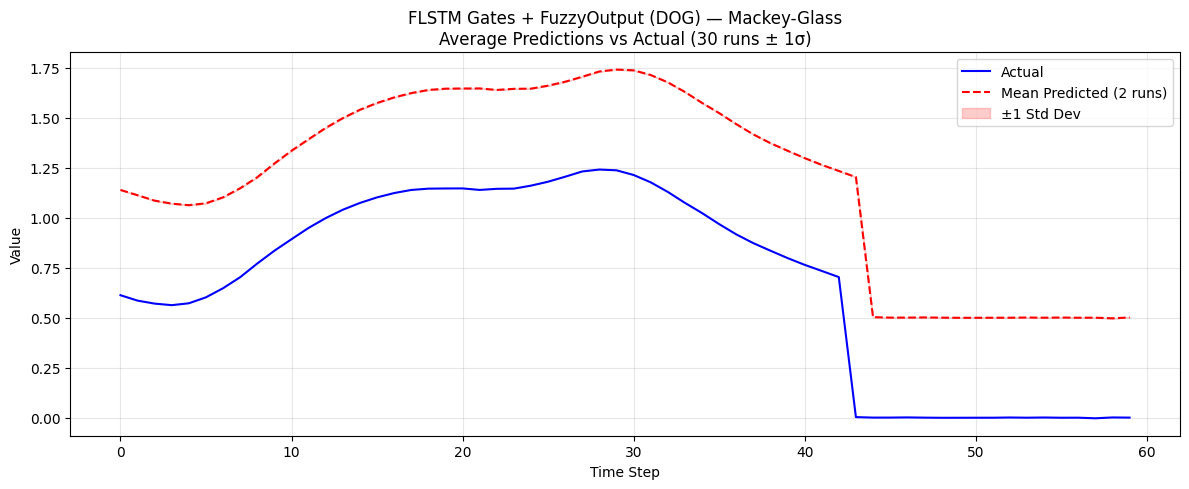

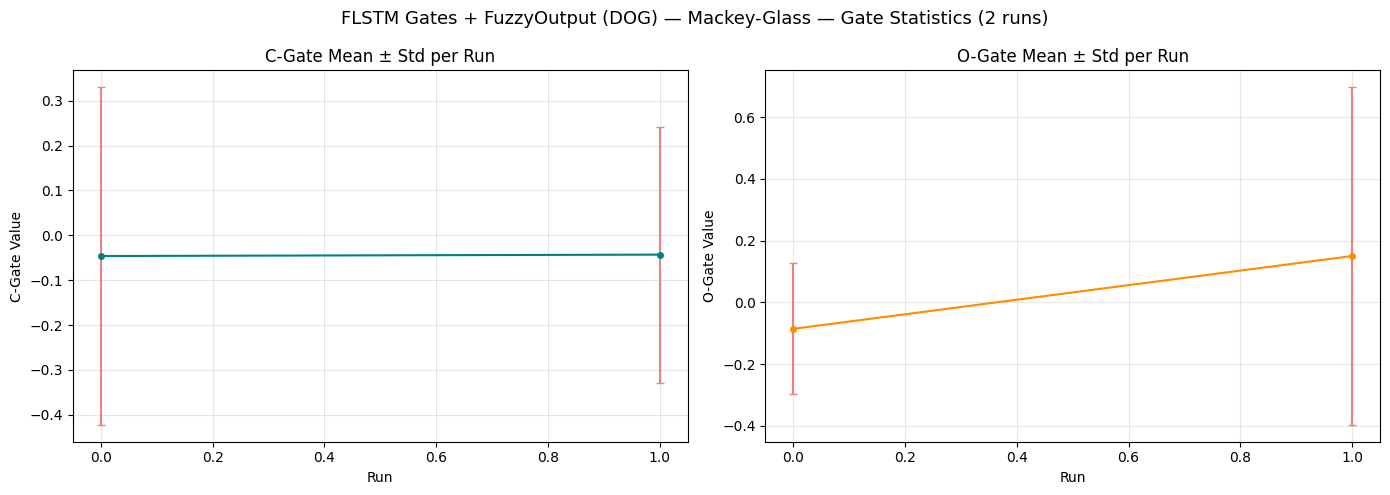

=== Best Run Metrics ===
RMSE: 0.519441
MAE:  0.510721

=== Average Metrics (2 runs) ===
RMSE: 0.519441 ± 0.000000
MAE:  0.510721 ± 0.000000

EVALUATING NOISE LEVEL: 5.0% (lambda=0.05, sigma=0.014455)


===== RUN 1/2 =====


Run 1 — RMSE: 0.519996, MAE: 0.511554 (Gate Mean C: 0.0002)

===== RUN 2/2 =====


Run 2 — RMSE: 0.519996, MAE: 0.511554 (Gate Mean C: 0.0666)

===== GATE STATISTICS =====
C-Gate - Mean: 0.0334, Min: -0.9612, Max: 0.9986
O-Gate - Mean: -0.1209, Min: -0.9997, Max: 0.9810

Overall RMSE: 0.519996

===== FINAL RESULTS — FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass (2 runs) =====
RMSE: 0.519996 ± 0.000000 (Var: 0.000000)
MAE:  0.511554 ± 0.000000

Best run: 1
  RMSE: 0.519996
  MAE:  0.511554


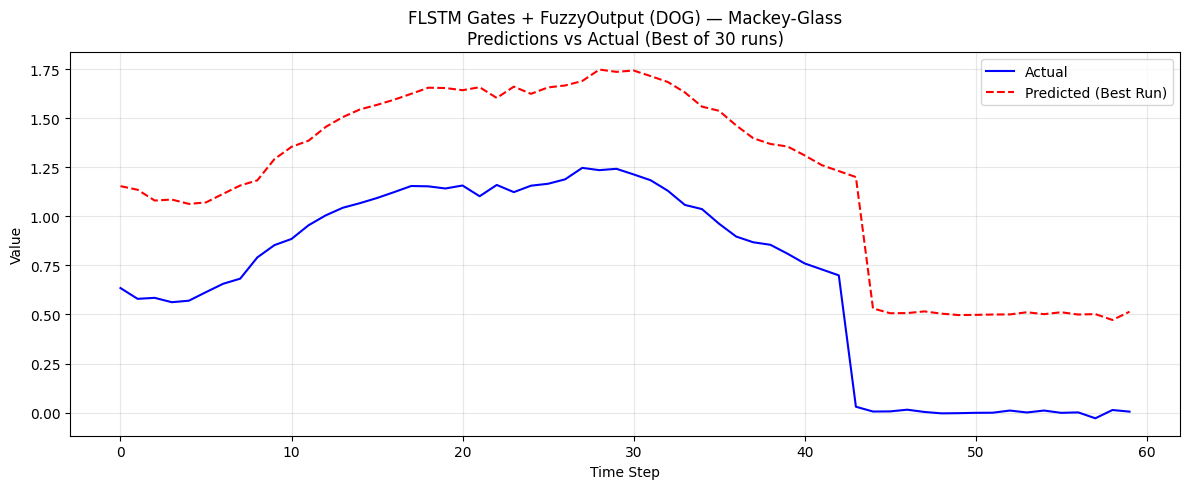

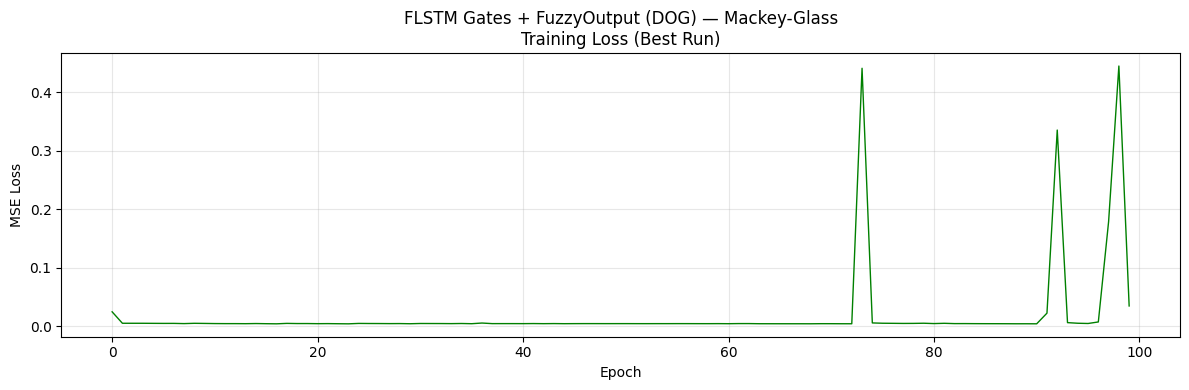

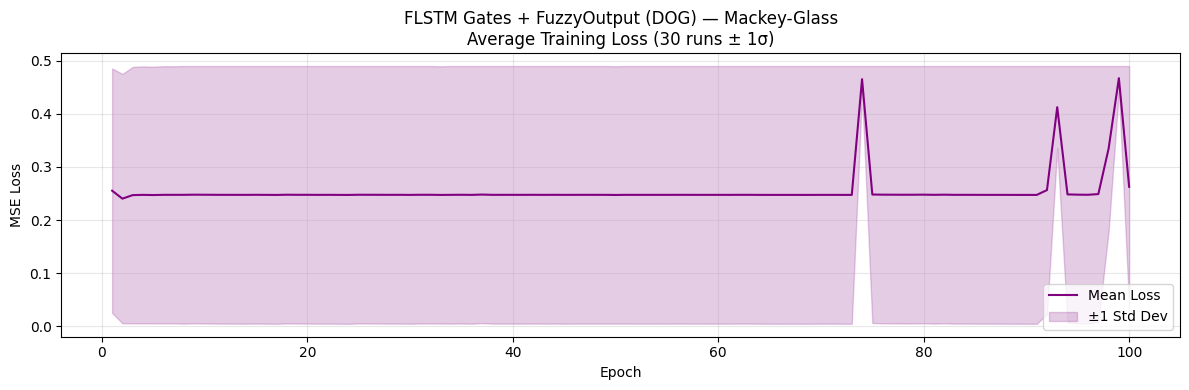

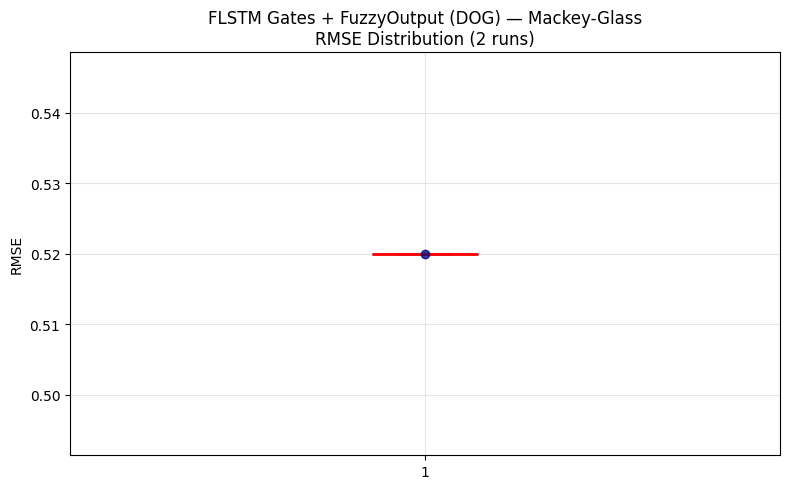

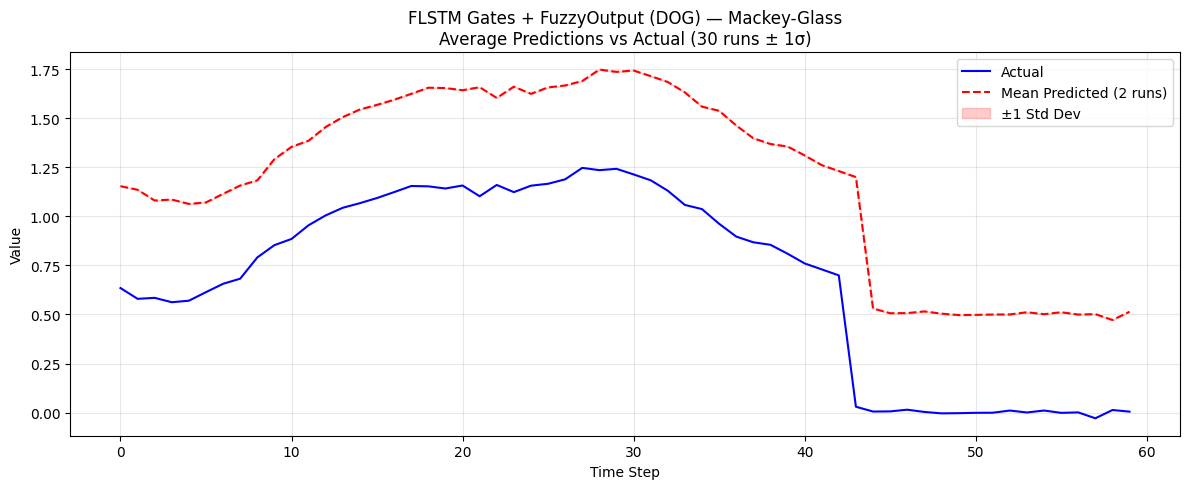

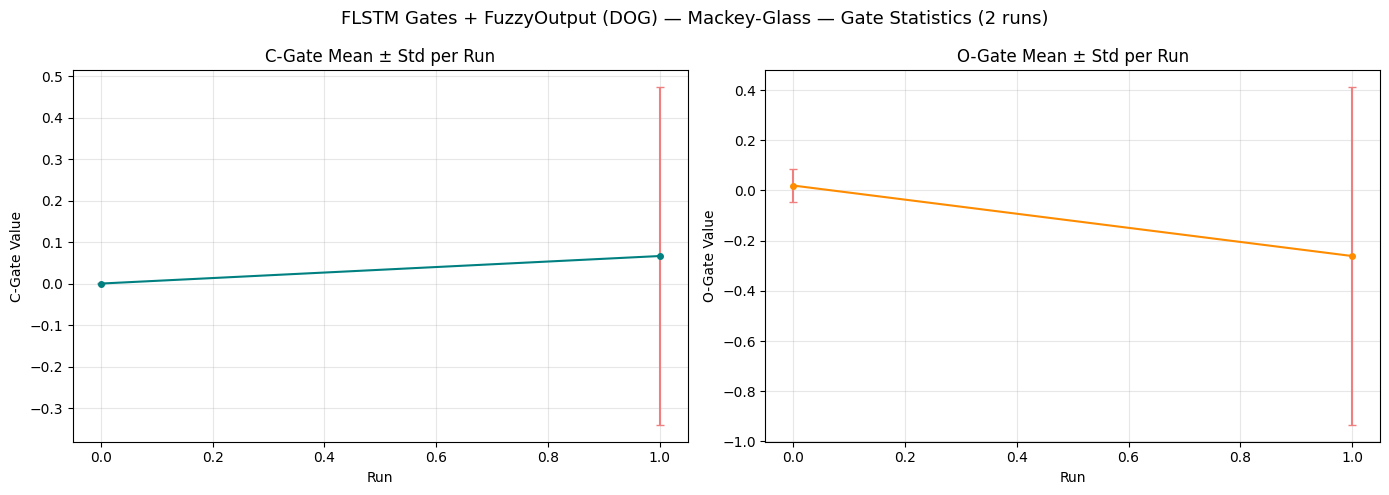

=== Best Run Metrics ===
RMSE: 0.519996
MAE:  0.511554

=== Average Metrics (2 runs) ===
RMSE: 0.519996 ± 0.000000
MAE:  0.511554 ± 0.000000

EVALUATING NOISE LEVEL: 10.0% (lambda=0.1, sigma=0.028910)


===== RUN 1/2 =====


Run 1 — RMSE: 0.521417, MAE: 0.512481 (Gate Mean C: -0.1316)

===== RUN 2/2 =====


Run 2 — RMSE: 0.521417, MAE: 0.512481 (Gate Mean C: 0.0227)

===== GATE STATISTICS =====
C-Gate - Mean: -0.0545, Min: -0.9674, Max: 0.3538
O-Gate - Mean: -0.0128, Min: -0.7870, Max: 0.5124

Overall RMSE: 0.521417

===== FINAL RESULTS — FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass (2 runs) =====
RMSE: 0.521417 ± 0.000000 (Var: 0.000000)
MAE:  0.512481 ± 0.000000

Best run: 1
  RMSE: 0.521417
  MAE:  0.512481


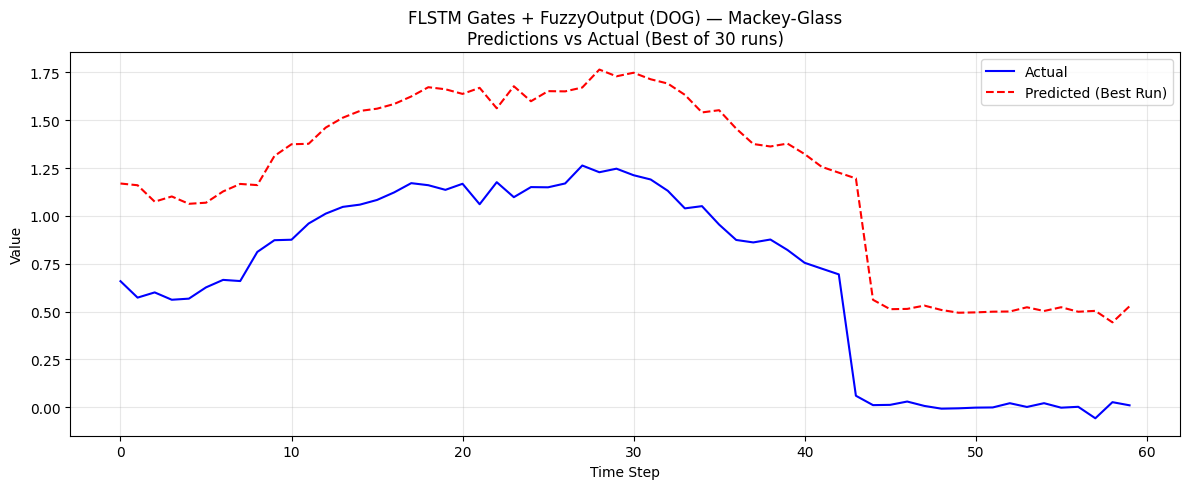

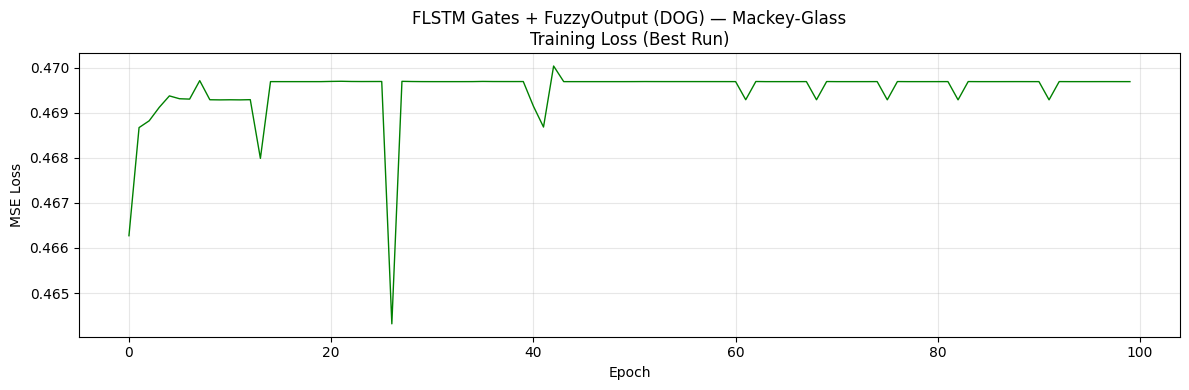

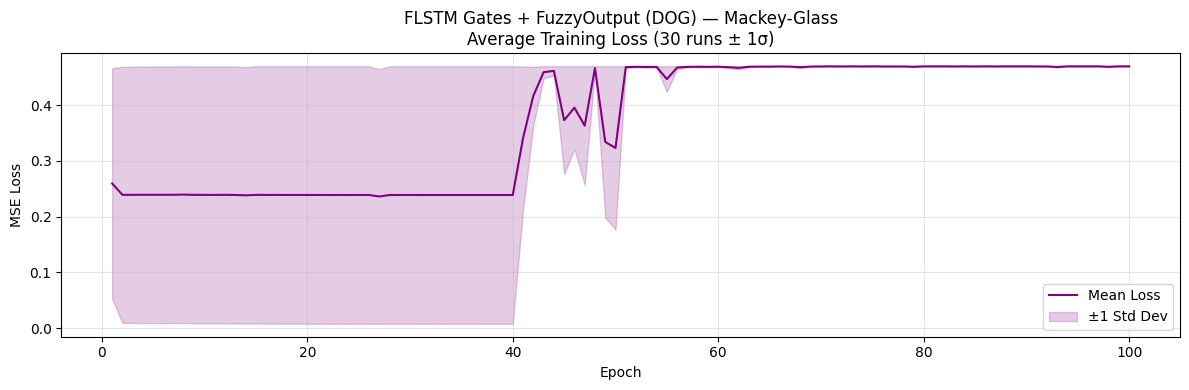

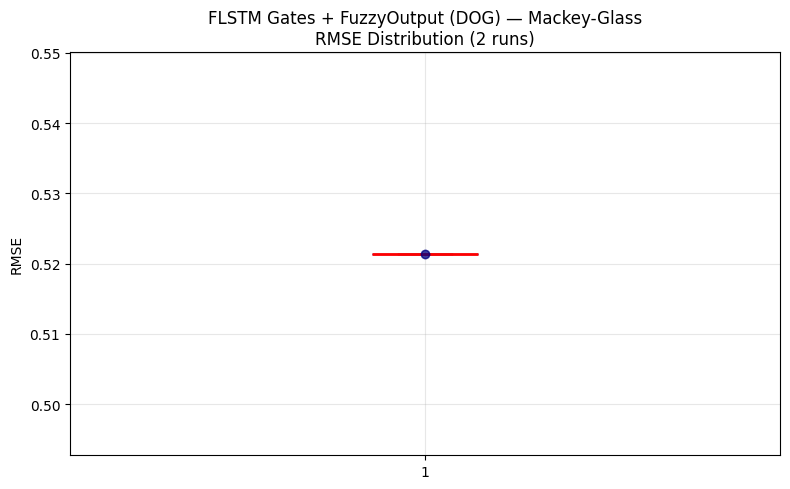

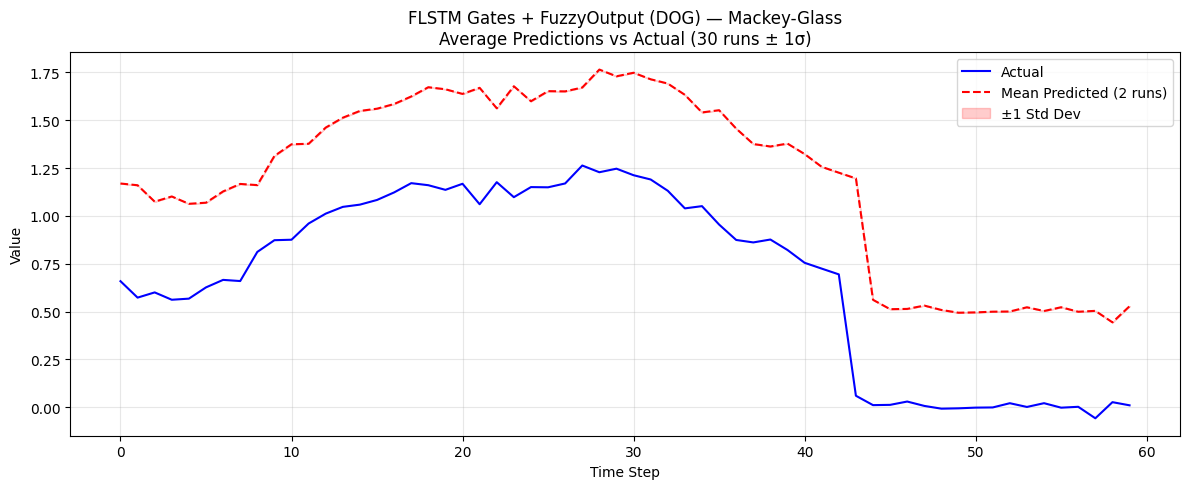

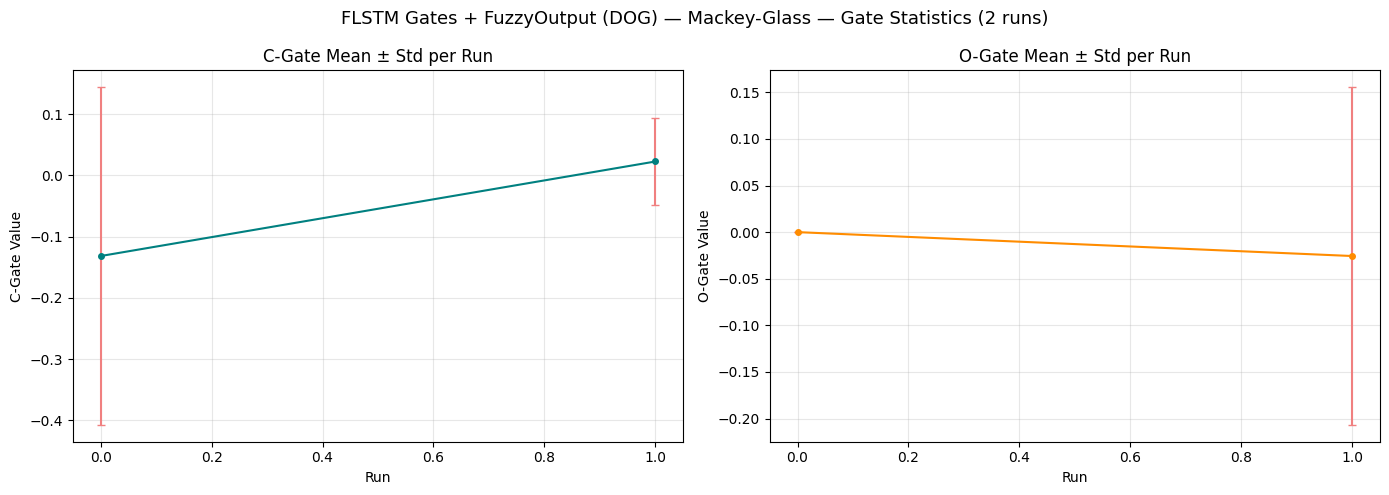

=== Best Run Metrics ===
RMSE: 0.521417
MAE:  0.512481

=== Average Metrics (2 runs) ===
RMSE: 0.521417 ± 0.000000
MAE:  0.512481 ± 0.000000

╔══════════════════════════════════════════════════════════════════════════════╗
║ COMBINED RESULTS (2 runs)                                                    ║
╠═══════════════╦══════════════════════════════╦═══════════════════════════════╣
║ Noise Level   ║ RMSE ± std                   ║ MAE ± std                     ║
╠═══════════════╬══════════════════════════════╬═══════════════════════════════╣
║ 0% (No Noise) ║ 0.091969 ± 0.004370          ║ 0.029656 ± 0.008062           ║
║ 0.5%          ║ 0.519441 ± 0.000000          ║ 0.510721 ± 0.000000           ║
║ 5.0%          ║ 0.519996 ± 0.000000          ║ 0.511554 ± 0.000000           ║
║ 10.0%         ║ 0.521417 ± 0.000000          ║ 0.512481 ± 0.000000           ║
╚═══════════════╩══════════════════════════════╩═══════════════════════════════╝


In [9]:
import openpyxl
series = pd.read_excel('../content/Mackey-Glass Time Series(taw17).xlsx')
raw_values = series['t+1'].values.flatten()
import numpy as np
original_raw_values = np.copy(raw_values)
s_x = np.std(original_raw_values)
noise_levels = [0.0, 0.005, 0.05, 0.1]

summary_results = {}

for lam in noise_levels:
    sigma = lam * s_x
    print("\n" + "="*80)
    if lam == 0.0:
        print(f"EVALUATING: NO NOISE (lambda=0)")
    else:
        print(f"EVALUATING NOISE LEVEL: {lam*100:.1f}% (lambda={lam}, sigma={sigma:.6f})")
    print("="*80 + "\n")
    
    np.random.seed(42)
    tf.random.set_seed(42)
    if lam > 0:
        noise = np.random.normal(0, sigma, size=original_raw_values.shape)
        raw_values = original_raw_values + noise
    else:
        raw_values = np.copy(original_raw_values)
    
    
    def difference(dataset, interval=1):
        diff = []
        for i in range(interval, len(dataset)):
            value = dataset[i] - dataset[i - interval]
            diff.append(value)
        return np.array(diff)
    
    diff_values = difference(raw_values, 1)
    def timeseries_to_supervised(data, lag):
        df = pd.DataFrame(data)
        columns = [df.shift(i) for i in range(1, lag+1)]
        columns.append(df)
        df = pd.concat(columns, axis=1)
        df.fillna(0, inplace=True)
        return df.values
    
    
    
    supervised = timeseries_to_supervised(diff_values, 1)
    train, test = supervised[:-60], supervised[-60:]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)
    
    X_train_raw, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
    X_test_raw, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
    
    # Build WM fuzzy system from training data
    wm_rules, wm_fs_x, wm_centers_y = build_wm_system(X_train_raw, y_train)
    
    # Compute WM fuzzy predictions r_t for gate fusion
    r_train = compute_fuzzy_predictions(X_train_raw, wm_rules, wm_fs_x, wm_centers_y)
    r_test = compute_fuzzy_predictions(X_test_raw, wm_rules, wm_fs_x, wm_centers_y)
    
    # Concatenate r_t as last feature: [x_t, r_t]
    X_train_aug = np.column_stack([X_train_raw, r_train])
    X_test_aug = np.column_stack([X_test_raw, r_test])
    
    X_train = X_train_aug.reshape((X_train_aug.shape[0], 1, X_train_aug.shape[1]))
    X_test = X_test_aug.reshape((X_test_aug.shape[0], 1, X_test_aug.shape[1]))
    
    all_rmse, all_mae = [], []
    all_predictions = []
    all_losses = []
    all_c_means, all_c_stds, all_c_mins, all_c_maxs = [], [], [], []
    all_o_means, all_o_stds, all_o_mins, all_o_maxs = [], [], [], []
    
    for run in range(2):
        print(f'\n===== RUN {run+1}/2 =====')
        np.random.seed(run)
        tf.random.set_seed(run)
        tf.keras.backend.clear_session()
        
        model = build_model(input_dim=2, units=8, batch_size=1)
        rnn_layer = model.layers[1]
        
        run_losses = []
        for epoch in range(100):
            history = model.fit(X_train, y_train, epochs=1, batch_size=1, verbose=0, shuffle=False)
            run_losses.append(history.history['loss'][0])
            rnn_layer.reset_states()
        all_losses.append(run_losses)
    
        # Warmup
        for i in range(len(X_train)): model.predict(X_train[i:i+1], batch_size=1, verbose=0)
    
        predictions, c_gates, o_gates = [], [], []
        for i in range(len(X_test)):
            yhat, c_val, o_val = model.predict(X_test[i:i+1], batch_size=1, verbose=0)
            c_gates.append(c_val[0])
            o_gates.append(o_val[0])
            
            row = list(X_test_raw[i]) + [yhat[0, 0]]
            inv = scaler.inverse_transform([row])[0, -1] + raw_values[len(train) + i]
            predictions.append(inv)
            
        c_gates, o_gates = np.array(c_gates), np.array(o_gates)
        all_c_means.append(np.mean(c_gates)); all_c_stds.append(np.std(c_gates))
        all_c_mins.append(np.min(c_gates)); all_c_maxs.append(np.max(c_gates))
        all_o_means.append(np.mean(o_gates)); all_o_stds.append(np.std(o_gates))
        all_o_mins.append(np.min(o_gates)); all_o_maxs.append(np.max(o_gates))
    
        actual = raw_values[-60:]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mae = np.mean(np.abs(np.array(actual) - np.array(predictions)))
        
        all_rmse.append(rmse)
        all_mae.append(mae)
        all_predictions.append(predictions)
        print(f'Run {run+1} — RMSE: {rmse:.6f}, MAE: {mae:.6f} (Gate Mean C: {np.mean(c_gates):.4f})')
    
    print('\n===== GATE STATISTICS =====')
    print(f'C-Gate - Mean: {np.mean(all_c_means):.4f}, Min: {np.min(all_c_mins):.4f}, Max: {np.max(all_c_maxs):.4f}')
    print(f'O-Gate - Mean: {np.mean(all_o_means):.4f}, Min: {np.min(all_o_mins):.4f}, Max: {np.max(all_o_maxs):.4f}')
    print(f'\nOverall RMSE: {np.mean(all_rmse):.6f}')
    
    
    # Summary Statistics (2 runs)
    
    print('\n===== FINAL RESULTS — FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass (2 runs) =====')
    mean_rmse = np.mean(all_rmse)
    std_rmse = np.std(all_rmse)
    var_rmse = np.var(all_rmse)
    
    mean_mae = np.mean(all_mae)
    std_mae = np.std(all_mae)
    
    print(f'RMSE: {mean_rmse:.6f} ± {std_rmse:.6f} (Var: {var_rmse:.6f})')
    print(f'MAE:  {mean_mae:.6f} ± {std_mae:.6f}')
    
    best_idx = np.argmin(all_rmse)
    
    print(f'\nBest run: {best_idx+1}')
    print(f'  RMSE: {all_rmse[best_idx]:.6f}')
    print(f'  MAE:  {all_mae[best_idx]:.6f}')
    
    # Predictions vs Actual (Best Run)
    
    actual = raw_values[-60:]
    best_predictions = all_predictions[best_idx]
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
             linewidth=1.5, linestyle='--')
    plt.title('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass\nPredictions vs Actual (Best of 30 runs)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Loss Curve (Best Run)
    
    plt.figure(figsize=(12, 4))
    plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
    plt.title('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass\nTraining Loss (Best Run)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Average Loss Curve (All 30 Runs)
    
    avg_losses = np.mean(all_losses, axis=0)
    std_losses = np.std(all_losses, axis=0)
    epochs = np.arange(1, len(avg_losses) + 1)
    
    plt.figure(figsize=(12, 4))
    plt.plot(epochs, avg_losses, color='purple', linewidth=1.5, label='Mean Loss')
    plt.fill_between(epochs, avg_losses - std_losses, avg_losses + std_losses,
                     alpha=0.2, color='purple', label='±1 Std Dev')
    plt.title('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass\nAverage Training Loss (30 runs ± 1σ)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # RMSE Distribution (Boxplot + All Points)
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(all_rmse, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
    plt.scatter(np.ones(len(all_rmse)), all_rmse, alpha=0.5, color='navy', zorder=5)
    plt.title('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass\nRMSE Distribution (2 runs)')
    plt.ylabel('RMSE')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Average Predictions vs Actual
    
    avg_predictions = np.mean(all_predictions, axis=0)
    std_predictions = np.std(all_predictions, axis=0)
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(avg_predictions, label='Mean Predicted (2 runs)', color='red',
             linewidth=1.5, linestyle='--')
    plt.fill_between(range(len(actual)),
                     avg_predictions - std_predictions,
                     avg_predictions + std_predictions,
                     alpha=0.2, color='red', label='±1 Std Dev')
    plt.title('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass\nAverage Predictions vs Actual (30 runs ± 1σ)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Gate Statistics Visualization
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # C-Gate statistics
    axes[0].errorbar(range(len(all_c_means)), all_c_means, yerr=all_c_stds,
                     fmt='o-', color='teal', ecolor='lightcoral', capsize=3, markersize=4)
    axes[0].set_title('C-Gate Mean ± Std per Run')
    axes[0].set_xlabel('Run')
    axes[0].set_ylabel('C-Gate Value')
    axes[0].grid(True, alpha=0.3)
    
    # O-Gate statistics
    axes[1].errorbar(range(len(all_o_means)), all_o_means, yerr=all_o_stds,
                     fmt='o-', color='darkorange', ecolor='lightcoral', capsize=3, markersize=4)
    axes[1].set_title('O-Gate Mean ± Std per Run')
    axes[1].set_xlabel('Run')
    axes[1].set_ylabel('O-Gate Value')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('FLSTM Gates + FuzzyOutput (DOG) — Mackey-Glass — Gate Statistics (2 runs)', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Final Metrics Summary
    
    print('=== Best Run Metrics ===')
    print(f'RMSE: {all_rmse[best_idx]:.6f}')
    print(f'MAE:  {all_mae[best_idx]:.6f}')
    
    print('\n=== Average Metrics (2 runs) ===')
    print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
    print(f'MAE:  {np.mean(all_mae):.6f} ± {np.std(all_mae):.6f}')
    summary_results[lam] = {'rmse_mean': mean_rmse, 'rmse_std': std_rmse, 'mae_mean': mean_mae, 'mae_std': std_mae}
    

# ==========================================
# COMBINED SUMMARY FOR ALL NOISE LEVELS
# ==========================================
print("\n" + "╔" + "═"*78 + "╗")
print(f"║ COMBINED RESULTS (2 runs) ".ljust(79) + "║")
print("╠" + "═"*15 + "╦" + "═"*30 + "╦" + "═"*31 + "╣")
print("║ Noise Level   ║ RMSE ± std                   ║ MAE ± std                     ║")
print("╠" + "═"*15 + "╬" + "═"*30 + "╬" + "═"*31 + "╣")
for lam in noise_levels:
    res = summary_results[lam]
    noise_str = "0% (No Noise)" if lam == 0.0 else f"{lam*100:.1f}%"
    rmse_str = f"{res['rmse_mean']:.6f} ± {res['rmse_std']:.6f}"
    mae_str = f"{res['mae_mean']:.6f} ± {res['mae_std']:.6f}"
    print(f"║ {noise_str:<13} ║ {rmse_str:<28} ║ {mae_str:<29} ║")
print("╚" + "═"*15 + "╩" + "═"*30 + "╩" + "═"*31 + "╝")


## Results

## Observations

### FLSTM Gates + FuzzyOutput (DOG) on Mackey-Glass

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Average Behaviour**: Compare average predictions vs actual
4. **Gate Dynamics**: Examine C-Gate and O-Gate statistics across runs
5. **Prediction Tracking**: Assess how well predictions track actual values
6. **Computational Cost**: Note training time per run
7. **Noise Robustness**: Compare metrics across noise levels (0%, 0.5%, 5%, 10%)
8. **FLSTM Components**: Evaluate the impact of fuzzy prediction fusion and strengthening memory

*After running all variant notebooks, perform cross-variant comparison to evaluate 
whether the FLSTM interfacing improves performance over TSK interfacing.*


In [10]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")



Total notebook execution time: 0h 36m 36.54s
Total seconds: 2196.54
